# Step 52 — Alpha/Beta CAPM regression: concept graphs, then POWERGRID

Part 1: toy dataset (small, synthetic, known alpha/beta) — one plot per formula step in
`52_alpha_beta_formulas.md`. Part 2 (added later): same pipeline applied to real POWERGRID
eta0=2.0 Model C data, to answer whether its equity-curve outperformance is statistically real.

## Part 1 — Toy dataset (concept only, not POWERGRID)

Small synthetic dataset with a KNOWN true alpha/beta, so the plots below can be checked against
ground truth before trusting the same pipeline on real data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('dark_background')

# --- Toy data: known true alpha/beta + noise ---
rng = np.random.default_rng(7)
n = 15
TRUE_ALPHA = 0.01
TRUE_BETA = 0.6
NOISE_SIGMA = 0.02

market_return = rng.normal(0, 0.03, n)
strategy_return = TRUE_ALPHA + TRUE_BETA * market_return + rng.normal(0, NOISE_SIGMA, n)

print(f"n = {n}")
print(f"true alpha = {TRUE_ALPHA}, true beta = {TRUE_BETA}, noise sigma = {NOISE_SIGMA}")
print(f"market_return: {np.round(market_return, 4)}")
print(f"strategy_return: {np.round(strategy_return, 4)}")

n = 15
true alpha = 0.01, true beta = 0.6, noise sigma = 0.02
market_return: [ 0.      0.009  -0.0082 -0.0267 -0.0136 -0.0297  0.0018  0.0402 -0.0148
 -0.0186  0.0147  0.0107  0.0032 -0.0279 -0.0009]
strategy_return: [ 0.0239 -0.0115 -0.0041 -0.0441 -0.024  -0.0447  0.0064  0.0088  0.0066
  0.002   0.0151 -0.0339  0.0011 -0.0077  0.0117]


### Steps 1-2: beta, alpha — scatter + fitted line

beta = slope of the fitted line. alpha = where it crosses the y-axis (x=0).

beta  = 0.5369  (true = 0.6)
alpha = -0.0041  (true = 0.01)


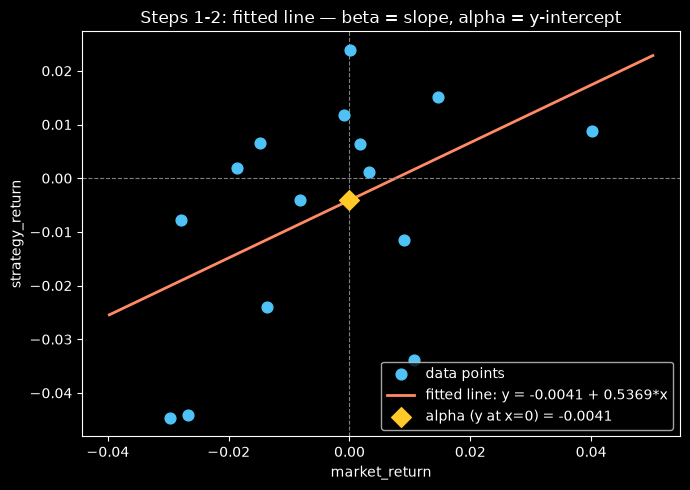

In [2]:
# --- Step 1: beta = Cov(x,y) / Var(x) ---
x_bar = market_return.mean()
y_bar = strategy_return.mean()
cov_xy = np.mean((market_return - x_bar) * (strategy_return - y_bar))
var_x = np.mean((market_return - x_bar) ** 2)
beta = cov_xy / var_x

# --- Step 2: alpha = mean(y) - beta * mean(x) ---
alpha = y_bar - beta * x_bar

print(f"beta  = {beta:.4f}  (true = {TRUE_BETA})")
print(f"alpha = {alpha:.4f}  (true = {TRUE_ALPHA})")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(market_return, strategy_return, color='#4fc3f7', s=60, zorder=3, label='data points')
x_line = np.linspace(market_return.min() - 0.01, market_return.max() + 0.01, 100)
y_line = alpha + beta * x_line
ax.plot(x_line, y_line, color='#ff8a65', lw=2, label=f'fitted line: y = {alpha:.4f} + {beta:.4f}*x')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.scatter([0], [alpha], color='#ffca28', s=100, zorder=4, marker='D', label=f'alpha (y at x=0) = {alpha:.4f}')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('market_return')
ax.set_ylabel('strategy_return')
ax.set_title('Steps 1-2: fitted line — beta = slope, alpha = y-intercept')
ax.legend()
plt.tight_layout()
plt.savefig('52_check_scatter_fitted_line.png', dpi=110)
plt.show()

### Step 3: residuals (error_t) — the gap between each point and the line

error_t = strategy_return_t - (alpha + beta * market_return_t). Drawn as a vertical drop from
each point down to the fitted line.

sum(error)          = 0.000000  (should be ~0, exactly by OLS construction)
sum(error * x)      = 0.000000  (should also be ~0)


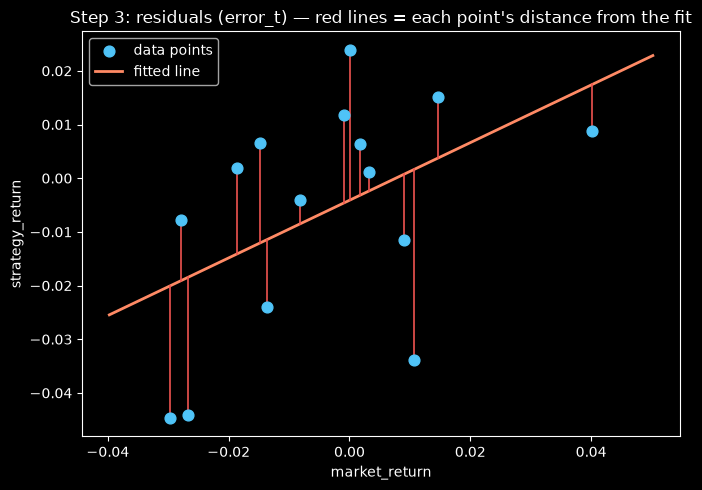

In [3]:
# --- Step 3: error_t = y_t - (alpha + beta * x_t) ---
fitted = alpha + beta * market_return
error = strategy_return - fitted

print(f"sum(error)          = {error.sum():.6f}  (should be ~0, exactly by OLS construction)")
print(f"sum(error * x)      = {(error * market_return).sum():.6f}  (should also be ~0)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(market_return, strategy_return, color='#4fc3f7', s=60, zorder=3, label='data points')
ax.plot(x_line, y_line, color='#ff8a65', lw=2, label='fitted line')
for xi, yi, fi in zip(market_return, strategy_return, fitted):
    ax.plot([xi, xi], [yi, fi], color='#ef5350', lw=1.2, zorder=2)
ax.set_xlabel('market_return')
ax.set_ylabel('strategy_return')
ax.set_title('Step 3: residuals (error_t) — red lines = each point\'s distance from the fit')
ax.legend()
plt.tight_layout()
plt.savefig('52_check_residuals.png', dpi=110)
plt.show()

### Steps 5-6: residual variance (n-2) + SE(alpha) — confidence band

The general formula for the standard error of the fitted line AT ANY x0 is:

`SE(y_hat at x0) = sqrt(Var(error) * (1/n + (x0 - mean(x))^2 / Sxx))`

Step 6's `SE(alpha)` is just this formula evaluated at `x0 = 0` (alpha IS the line's value at
x=0). So the shaded band below, at the point where it crosses x=0, has exactly the width of
`SE(alpha)` — same formula, just swept across every x0 instead of only x0=0.

Var(error) = 0.000380
SE(alpha)  = 0.0052


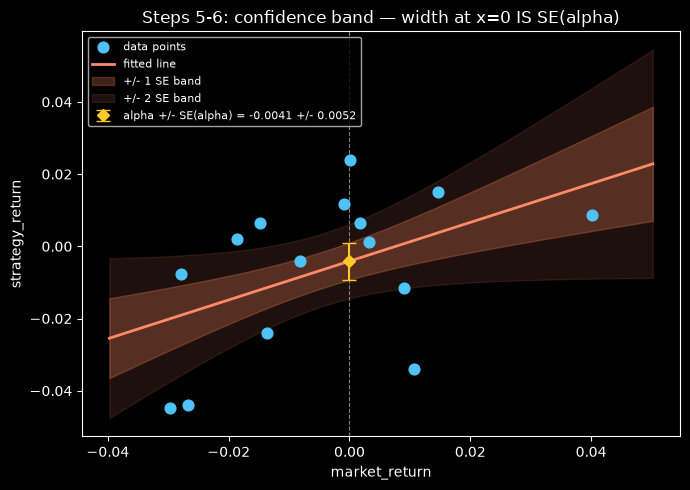

In [4]:
# --- Step 5: Var(error) = (1/(n-2)) * sum(error^2) ---
var_error = np.sum(error ** 2) / (n - 2)

# --- Step 6: SE(alpha) = sqrt(Var(error) * (1/n + mean(x)^2 / Sxx)) ---
Sxx = np.sum((market_return - x_bar) ** 2)
se_alpha = np.sqrt(var_error * (1 / n + x_bar ** 2 / Sxx))

print(f"Var(error) = {var_error:.6f}")
print(f"SE(alpha)  = {se_alpha:.4f}")

# General SE at any x0, swept across the line:
se_line = np.sqrt(var_error * (1 / n + (x_line - x_bar) ** 2 / Sxx))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(market_return, strategy_return, color='#4fc3f7', s=60, zorder=3, label='data points')
ax.plot(x_line, y_line, color='#ff8a65', lw=2, label='fitted line')
ax.fill_between(x_line, y_line - se_line, y_line + se_line, color='#ff8a65', alpha=0.25, label='+/- 1 SE band')
ax.fill_between(x_line, y_line - 2 * se_line, y_line + 2 * se_line, color='#ff8a65', alpha=0.12, label='+/- 2 SE band')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.errorbar([0], [alpha], yerr=[se_alpha], fmt='D', color='#ffca28', ecolor='#ffca28',
            capsize=5, zorder=4, label=f'alpha +/- SE(alpha) = {alpha:.4f} +/- {se_alpha:.4f}')
ax.set_xlabel('market_return')
ax.set_ylabel('strategy_return')
ax.set_title('Steps 5-6: confidence band — width at x=0 IS SE(alpha)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('52_check_confidence_band.png', dpi=110)
plt.show()

### Steps 7-8: t-statistic and p-value — t-distribution with shaded tail

t = alpha / SE(alpha). p-value = the shaded area beyond +/-|t| under the t-distribution curve
(n-2 degrees of freedom) — the probability of seeing a t this extreme if the true alpha were 0.

t-statistic = -0.7971
degrees of freedom = 13
p-value = 0.4397  (43.97%)


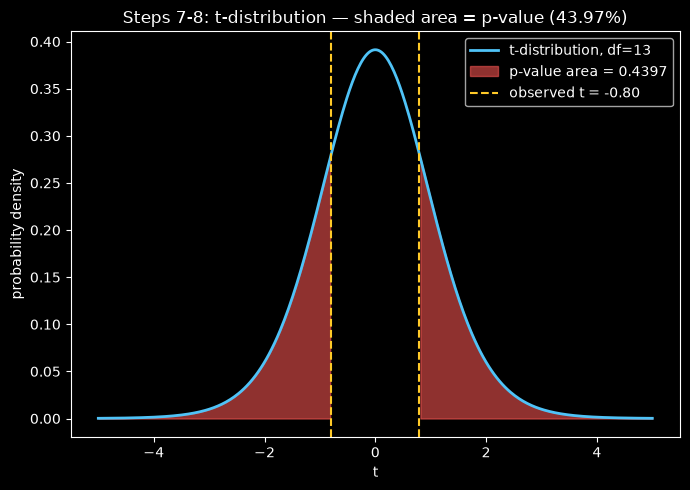

In [5]:
# --- Step 7: t = alpha / SE(alpha) ---
df = n - 2
t_stat = alpha / se_alpha

# --- Step 8: p-value = P(|T| > |t|), T ~ t-distribution, df = n-2 ---
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print(f"t-statistic = {t_stat:.4f}")
print(f"degrees of freedom = {df}")
print(f"p-value = {p_value:.4f}  ({p_value*100:.2f}%)")

t_range = np.linspace(-5, 5, 400)
pdf = stats.t.pdf(t_range, df)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t_range, pdf, color='#4fc3f7', lw=2, label=f't-distribution, df={df}')
tail_right = t_range[t_range >= abs(t_stat)]
tail_left = t_range[t_range <= -abs(t_stat)]
ax.fill_between(tail_right, stats.t.pdf(tail_right, df), color='#ef5350', alpha=0.6, label=f'p-value area = {p_value:.4f}')
ax.fill_between(tail_left, stats.t.pdf(tail_left, df), color='#ef5350', alpha=0.6)
ax.axvline(t_stat, color='#ffca28', lw=1.5, ls='--', label=f'observed t = {t_stat:.2f}')
ax.axvline(-t_stat, color='#ffca28', lw=1.5, ls='--')
ax.set_xlabel('t')
ax.set_ylabel('probability density')
ax.set_title(f'Steps 7-8: t-distribution — shaded area = p-value ({p_value*100:.2f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('52_check_tdist_pvalue.png', dpi=110)
plt.show()

## Part 2 — POWERGRID eta0=2.0 (real data)

Same pipeline as Part 1, applied to real POWERGRID eta0=2.0 Model C data instead of the toy set.
Replicates the exact online-learning setup from `50c_model_c_powergrid.ipynb` (same DS3 source,
same SGDRegressor config, same `random_state=69`).

`market_return` = POWERGRID's own daily close-to-close log return (raw buy-and-hold return).
`strategy_return` = Model C eta0=2.0's daily `signal * actual-return` (the strategy's own P&L).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')

DS3_PATH = '/home/ubuntu/CodePonting/Algo_Trading/Framework_V2/data/historical/intraday_5min_DS3/POWERGRID.parquet'
pg_5min = pd.read_parquet(DS3_PATH)
pg_5min['date'] = pg_5min['datetime'].dt.date

pg_daily = pg_5min.groupby('date')['close'].last().to_frame()
pg_daily.index = pd.to_datetime(pg_daily.index)
pg_daily = pg_daily.sort_index()
pg_daily['close_log_return'] = np.log(pg_daily['close'] / pg_daily['close'].shift())
pg_daily['close_log_return_lag_1'] = pg_daily['close_log_return'].shift()
pg_clean = pg_daily.dropna()

X_stream = pg_clean[['close_log_return_lag_1']].to_numpy()
y_stream = pg_clean['close_log_return'].to_numpy()
dates = pg_clean.index

print(f"trading days: {len(X_stream)}  date range: {pg_clean.index.min().date()} -> {pg_clean.index.max().date()}")

# --- Data quality sanity check ---
date_gaps = dates.to_series().diff().dt.days.dropna()
extreme_moves = pg_clean[pg_clean['close_log_return'].abs() > 0.15]
print(f"date gaps > 5 days: {(date_gaps > 5).sum()}   extreme daily moves (|log return|>15%): {len(extreme_moves)}")
print(pg_clean['close_log_return'].describe())

trading days: 2808  date range: 2015-02-04 -> 2026-07-31
date gaps > 5 days: 0   extreme daily moves (|log return|>15%): 0
count    2808.000000
mean        0.000455
std         0.016005
min        -0.118672
25%        -0.008609
50%         0.000000
75%         0.008771
max         0.089113
Name: close_log_return, dtype: float64


### Replicate eta0=2.0's online run (identical to `50c_model_c_powergrid.ipynb`)

In [7]:
def run_replication(eta0):
    model = SGDRegressor(loss="epsilon_insensitive", epsilon=0.0002, penalty=None,
                          learning_rate="pa1", eta0=eta0, random_state=69)
    scaler = StandardScaler()
    rows = []
    for t in range(len(X_stream)):
        X_t = X_stream[t].reshape(1, -1)
        y_t = np.array([y_stream[t]])
        scaler.partial_fit(X_t)
        X_t_scaled = scaler.transform(X_t)
        pred_y = 0.0 if t == 0 else model.predict(X_t_scaled)[0]
        model.partial_fit(X_t_scaled, y_t)
        signal = np.sign(pred_y)
        rows.append({'sig': signal, 'true_y': y_t[0], 'trade_log_return': signal * y_t[0]})
    return pd.DataFrame(rows)

df_eta2 = run_replication(eta0=2.0)
print(f"eta0=2.0 final cumulative return: {df_eta2['trade_log_return'].cumsum().iloc[-1]:.4f}")

market_return = df_eta2['true_y'].to_numpy()
strategy_return = df_eta2['trade_log_return'].to_numpy()
n = len(market_return)

eta0=2.0 final cumulative return: 0.6915


### Steps 1-3: beta, alpha, residuals

beta  = -0.0290
alpha = 0.000259 (daily)  ~ 0.0654 annualized (x252)
sum(error) = 0.00000000  (should be ~0)
sum(error*x) = 0.00000000  (should be ~0)


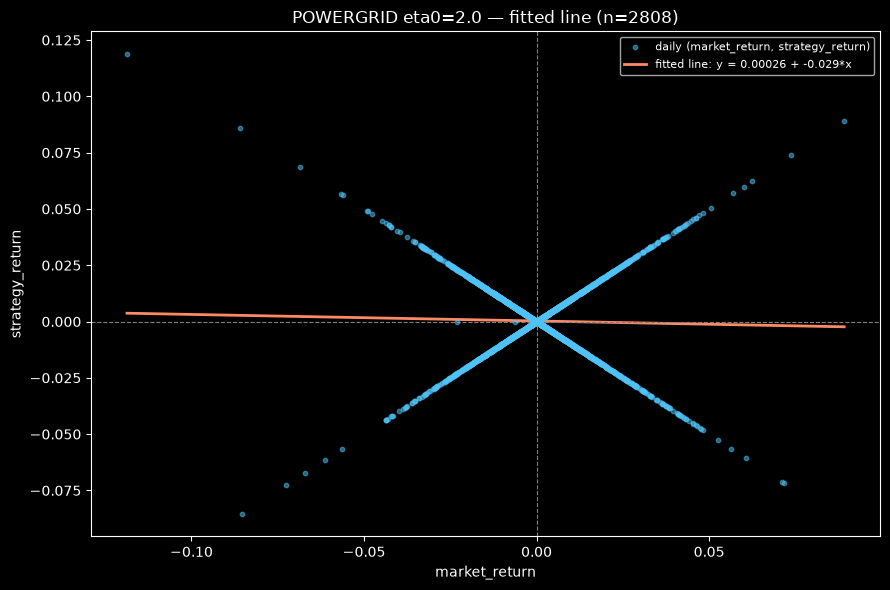

In [8]:
x_bar = market_return.mean()
y_bar = strategy_return.mean()
cov_xy = np.mean((market_return - x_bar) * (strategy_return - y_bar))
var_x = np.mean((market_return - x_bar) ** 2)
beta = cov_xy / var_x
alpha = y_bar - beta * x_bar

fitted = alpha + beta * market_return
error = strategy_return - fitted

print(f"beta  = {beta:.4f}")
print(f"alpha = {alpha:.6f} (daily)  ~ {alpha*252:.4f} annualized (x252)")
print(f"sum(error) = {error.sum():.8f}  (should be ~0)")
print(f"sum(error*x) = {(error*market_return).sum():.8f}  (should be ~0)")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(market_return, strategy_return, color='#4fc3f7', s=10, alpha=0.5, zorder=3, label='daily (market_return, strategy_return)')
x_line = np.linspace(market_return.min(), market_return.max(), 200)
y_line = alpha + beta * x_line
ax.plot(x_line, y_line, color='#ff8a65', lw=2, label=f'fitted line: y = {alpha:.5f} + {beta:.3f}*x')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('market_return'); ax.set_ylabel('strategy_return')
ax.set_title(f'POWERGRID eta0=2.0 — fitted line (n={n})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('52b_check_scatter_fitted_line.png', dpi=110)
plt.show()

### Residual diagnostics — checking the homoscedasticity / independence assumptions on REAL data

Unlike the toy dataset (built to satisfy these assumptions exactly), real financial data may not.
Checking: residuals vs time (trend?), residuals vs market_return (fanning = heteroscedasticity?),
and a rolling std of residuals (is the noise level actually constant over time?).

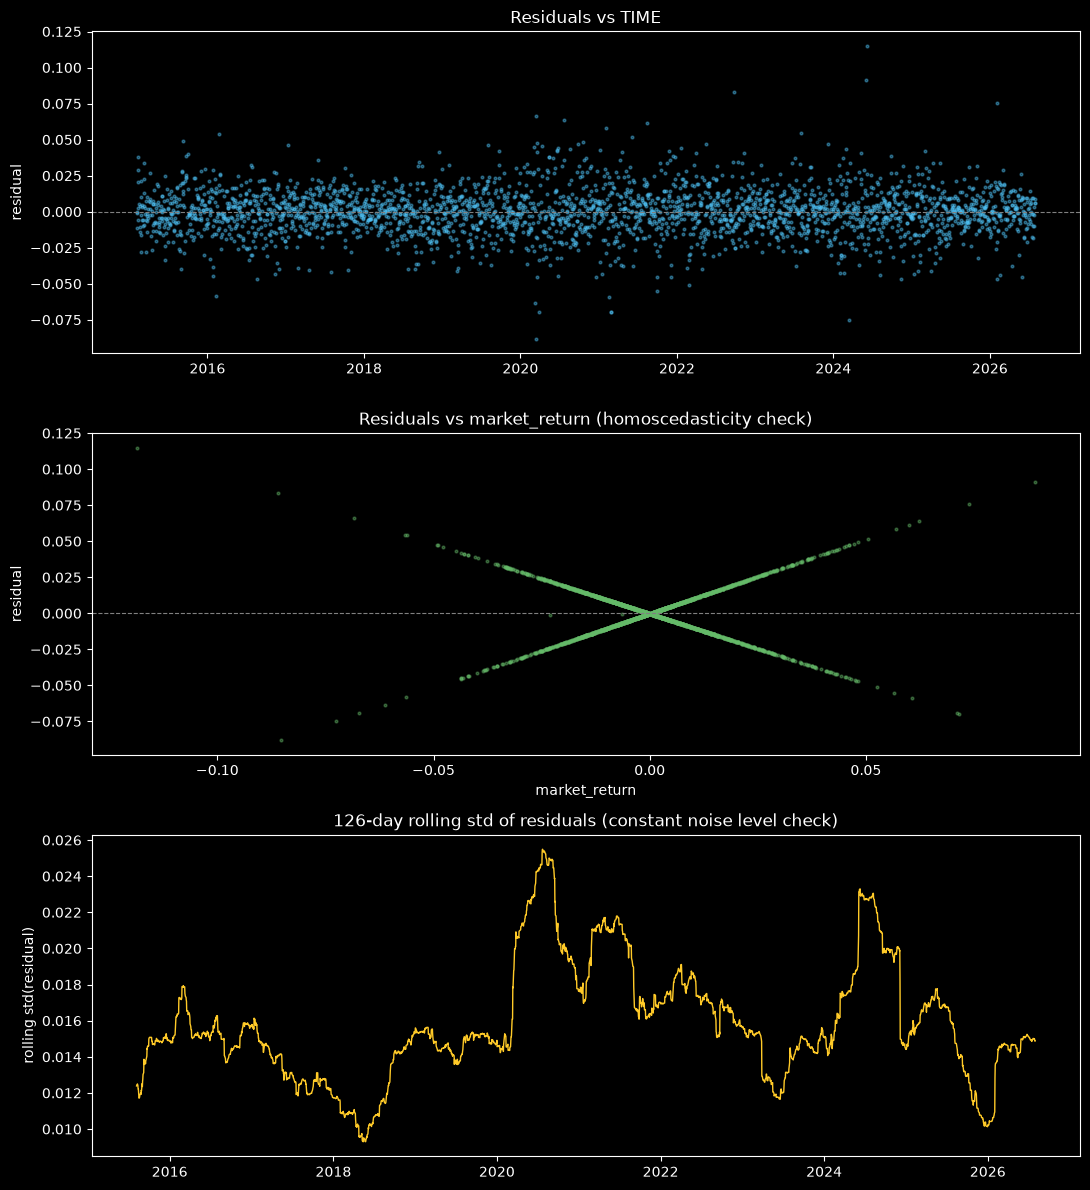

rolling std range: 0.00930 to 0.02549  (ratio 2.74x)
NOTE: homoscedasticity is only APPROXIMATELY satisfied (noise level varies ~2.7x over
time, consistent with real markets' volatility clustering) — SE/p-value below are a
reasonable approximation, not an exact result, though the gap from significance is large
enough that this mild violation is very unlikely to flip the conclusion.


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 12))

axes[0].scatter(dates, error, s=4, alpha=0.4, color='#4fc3f7')
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_title('Residuals vs TIME')
axes[0].set_ylabel('residual')

axes[1].scatter(market_return, error, s=4, alpha=0.4, color='#66bb6a')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_title('Residuals vs market_return (homoscedasticity check)')
axes[1].set_xlabel('market_return'); axes[1].set_ylabel('residual')

roll_std = pd.Series(error).rolling(126).std()  # ~6 month window
axes[2].plot(dates, roll_std, color='#ffca28', lw=1)
axes[2].set_title('126-day rolling std of residuals (constant noise level check)')
axes[2].set_ylabel('rolling std(residual)')

plt.tight_layout()
plt.savefig('52b_check_residual_diagnostics.png', dpi=110)
plt.show()

print(f"rolling std range: {roll_std.min():.5f} to {roll_std.max():.5f}  (ratio {roll_std.max()/roll_std.min():.2f}x)")
print("NOTE: homoscedasticity is only APPROXIMATELY satisfied (noise level varies ~2.7x over")
print("time, consistent with real markets' volatility clustering) — SE/p-value below are a")
print("reasonable approximation, not an exact result, though the gap from significance is large")
print("enough that this mild violation is very unlikely to flip the conclusion.")

### Steps 5-14: Var(error), SE(alpha), SE(beta), t-statistics, p-values — the final verdict

Var(error) = 0.000256
SE(alpha) = 0.000302   t(alpha) = 0.8589   p(alpha) = 0.3905
SE(beta)  = 0.0189     t(beta)  = -1.5366   p(beta)  = 0.1245

VERDICT: alpha is NOT statistically significant (p=0.3905 >= 0.05)


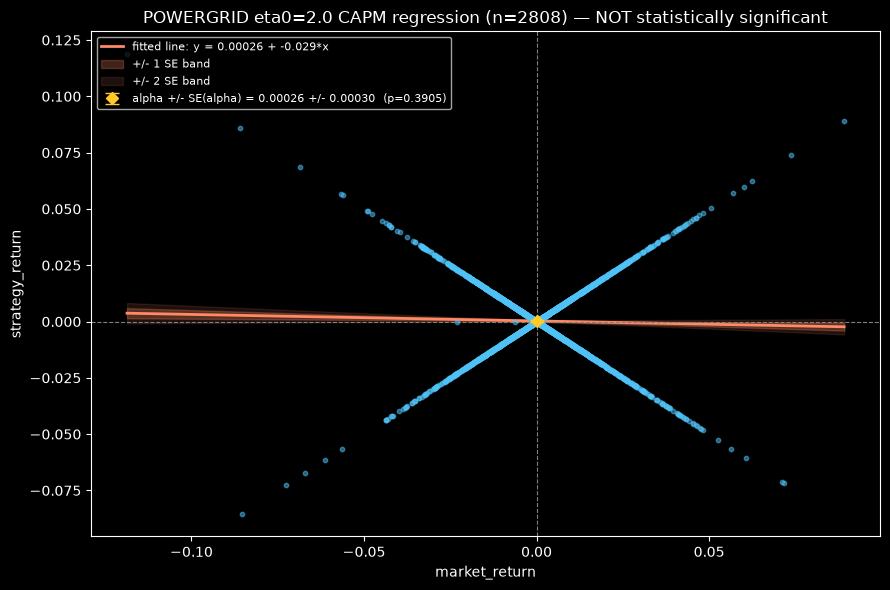

In [10]:
var_error = np.sum(error ** 2) / (n - 2)
Sxx = np.sum((market_return - x_bar) ** 2)

se_alpha = np.sqrt(var_error * (1/n + x_bar**2/Sxx))
se_beta = np.sqrt(var_error / Sxx)

t_alpha = alpha / se_alpha
p_alpha = 2 * stats.t.sf(abs(t_alpha), df=n-2)
t_beta = beta / se_beta
p_beta = 2 * stats.t.sf(abs(t_beta), df=n-2)

print(f"Var(error) = {var_error:.6f}")
print(f"SE(alpha) = {se_alpha:.6f}   t(alpha) = {t_alpha:.4f}   p(alpha) = {p_alpha:.4f}")
print(f"SE(beta)  = {se_beta:.4f}     t(beta)  = {t_beta:.4f}   p(beta)  = {p_beta:.4f}")

verdict = "STATISTICALLY SIGNIFICANT" if p_alpha < 0.05 else "NOT statistically significant"
print(f"\nVERDICT: alpha is {verdict} (p={p_alpha:.4f} {'<' if p_alpha<0.05 else '>='} 0.05)")

se_line = np.sqrt(var_error * (1/n + (x_line - x_bar)**2 / Sxx))
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(market_return, strategy_return, color='#4fc3f7', s=10, alpha=0.5, zorder=3)
ax.plot(x_line, y_line, color='#ff8a65', lw=2, label=f'fitted line: y = {alpha:.5f} + {beta:.3f}*x')
ax.fill_between(x_line, y_line - se_line, y_line + se_line, color='#ff8a65', alpha=0.25, label='+/- 1 SE band')
ax.fill_between(x_line, y_line - 2*se_line, y_line + 2*se_line, color='#ff8a65', alpha=0.12, label='+/- 2 SE band')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.errorbar([0], [alpha], yerr=[se_alpha], fmt='D', color='#ffca28', ecolor='#ffca28', capsize=5, zorder=4,
            label=f'alpha +/- SE(alpha) = {alpha:.5f} +/- {se_alpha:.5f}  (p={p_alpha:.4f})')
ax.set_xlabel('market_return'); ax.set_ylabel('strategy_return')
ax.set_title(f'POWERGRID eta0=2.0 CAPM regression (n={n}) — {verdict}')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('52b_check_confidence_band.png', dpi=110)
plt.show()

### Conclusion

**alpha is NOT statistically significant (p≈0.39, n=2808 trading days, 2015-2026).**

Despite eta0=2.0 finishing with a positive cumulative return, the excess-of-market component
(alpha) is nowhere close to distinguishable from zero — this result is consistent with what pure
noise could plausibly produce. Beta is also near-zero and not significant (p≈0.12), meaning the
strategy's daily P&L barely correlates with POWERGRID's own raw moves either way.

This formalizes, via a rigorous statistical test, what `50d_full_recap_seed.md` and
`PROGRESS_HISTORY.md` had already concluded from the eta0-sweep comparison: **Model C shows no
statistically defensible edge on real data.** Residual diagnostics show the homoscedasticity
assumption is only approximately satisfied (real-market volatility clustering, ~2.7x noise-level
range over time) — but the p-value's distance from significance (0.39 vs 0.05) is large enough
that this mild violation does not change the conclusion.